In [ ]:
from keras.models import Model
from keras.layers import Input, Dense
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
encoding_dim = 64

In [ ]:
input_img = Input(shape = (784,))

In [ ]:
encoded = Dense(encoding_dim, activation = 'relu')(input_img)
decoded = Dense(784, activation = 'sigmoid')(encoded)

In [ ]:
autocoder = Model(input_img, decoded)

In [ ]:
encoder = Model(input_img, encoded)

In [ ]:
encoded_input = Input(shape = (encoding_dim,))
decoder_layer = autocoder.layers[-1]
decoder = Model(encoded_input, decoder_layer(encoded_input))

In [ ]:
autocoder.compile(optimizer = 'adadelta', loss = 'binary_crossentropy')

In [ ]:
(x_train, _), (x_test,_) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [ ]:
x_train = x_train.reshape((len(x_train),(np.prod(x_train.shape[1:]))))
x_test = x_test.reshape((len(x_test),(np.prod(x_test.shape[1:]))))

In [ ]:
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [ ]:
autocoder.fit(x_train,x_train, epochs = 50, batch_size = 256, shuffle = True, validation_data = (x_test,x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.6917 - val_loss: 0.6915
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.6914 - val_loss: 0.6911
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.6911 - val_loss: 0.6908
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.6907 - val_loss: 0.6905
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.6905 - val_loss: 0.6902
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.6902 - val_loss: 0.6899
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.6898 - val_loss: 0.6896
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.6895 - val_loss: 0.6893
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.6892 - val_loss: 0.6890
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.6889 - val_loss: 0.6886
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.6886 - val_loss: 0.6883
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


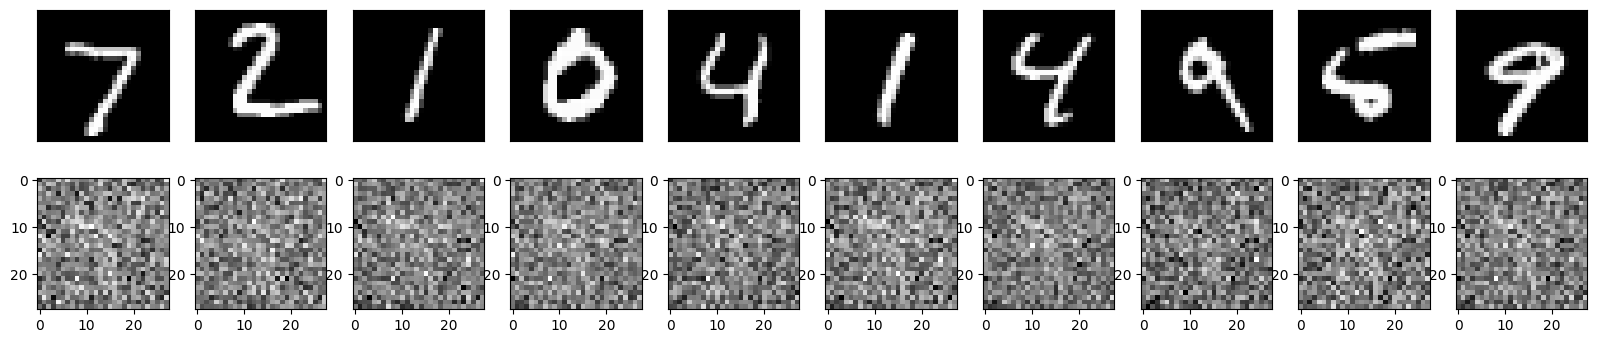

In [ ]:
n = 10

plt.figure(figsize = (20,4))
for i in range(n):
  ax = plt.subplot(2,n,i+1)
  plt.imshow(x_test[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
  av = plt.subplot(2,n,i+1+n)
  plt.imshow(decoded_imgs[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()